# 6장 2강: 허깅페이스 모델 실습
## 2. 트랜스포머 아키텍처별 모델 실습


### 2.2 인코더 모델 활용: KoBERT로 감정 분류

현재 연산에 사용 중인 디바이스: mps


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17251.59it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: rkdaldus/ko-sent5-classification
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- 분석 결과 ---
  Emotion  Probability
0      분노     0.099407
1      불안     0.245796
2      기쁨     0.199289
3      평온     0.215908
4      슬픔     0.239599


findfont: Failed to find font weight bold, now using 400.


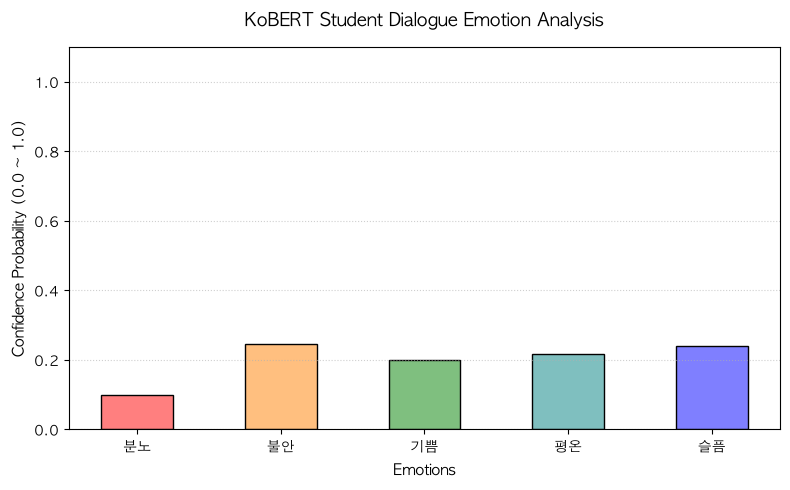

In [6]:
import platform
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# 사전 학습된 KoBERT 감정 분류 모델 및 토크나이저 로드
model_name = "rkdaldus/ko-sent5-classification"
tokenizer = AutoTokenizer.from_pretrained("monologg/kobert", trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

# 분석 대상 입력 텍스트 정의
text_to_analyze = "이번 시험을 위해 밤을 새우며 정말 열심히 준비했는데 생각보다 점수가 너무 낮게 나와서 속상하고 눈물이 나네."

# 텍스트 토큰화 및 PyTorch 텐서 변환
encoded_inputs = tokenizer(text_to_analyze, return_tensors="pt", padding=True, truncation=True).to(device)

# 모델 추론을 통한 로짓(Logits) 값 추출
with torch.no_grad():
    model_outputs = model(**encoded_inputs)
    logits = model_outputs.logits

# Softmax 함수를 적용하여 감정별 확률 계산
calculated_probabilities = torch.nn.functional.softmax(logits, dim=-1).squeeze().tolist()

# 감정 레이블 매핑 및 데이터프레임 변환
emotion_labels = ["분노", "불안", "기쁨", "평온", "슬픔"]
emotion_df = pd.DataFrame({
    "Emotion": emotion_labels,
    "Probability": calculated_probabilities
})

print("--- 분석 결과 ---")
print(emotion_df)

# 분석 결과 시각화 (막대그래프)
plt.figure(figsize=(8, 5))
bar_colors = ["#ff7f7f", "#ffbf7f", "#7fbf7f", "#7fbfbf", "#7f7fff"]
plt.bar(emotion_df["Emotion"], emotion_df["Probability"], color=bar_colors, edgecolor="black", width=0.5)

plt.title("KoBERT Student Dialogue Emotion Analysis", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Emotions", fontsize=11)
plt.ylabel("Confidence Probability (0.0 ~ 1.0)", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 2.3 인코더-디코더 모델 활용: KoBART로 뉴스 요약

In [ ]:
from transformers import PreTrainedTokenizerFast, BartForConditionalGeneration

# KoBART 요약 모델 및 전용 토크나이저 로드
kobart_identifier = "gogamza/kobart-summarization"
bart_tokenizer = PreTrainedTokenizerFast.from_pretrained(kobart_identifier)
bart_model = BartForConditionalGeneration.from_pretrained(kobart_identifier).to(device)

# 요약 대상 원문 텍스트 정의
campus_news = (
    "이번 실증은 KOSA와 한국 풀스택 AI 컨소시엄이 지난 2월 아람코 디지털과 체결한 ‘AI 풀스택 협력 업무협약(MOU)’에 따라 추진됐다. 복잡한 산업 엔지니어링 데이터를 처리하는 과정에 국내 기업의 AI 반도체와 클라우드, 대규모언어모델(LLM), 응용 서비스 등을 통합 적용하는 방식이다."
    "실증에는 메가존클라우드와 퓨리오사AI, 리벨리온, 업스테이지, LG AI연구원, NC AI, 유라클 등 국내 기업 7곳이 참여했다. 메가존클라우드는 AI·멀티클라우드 인프라 구축과 운영을, 퓨리오사AI와 리벨리온은 AI 반도체를 각각 담당했다. 업스테이지와 LG AI연구원은 산업 특화 LLM, NC AI는 3차원(3D) 모델링, 유라클은 LLM·신경망처리장치(NPU) 운영과 AI 자원 관리 기술을 제공했다."
)

# 텍스트 인코딩 및 토큰화
input_ids = bart_tokenizer.encode(campus_news, return_tensors="pt", max_length=1024, truncation=True).to(device)

# 요약문 생성 (Beam Search 및 반복 방지 옵션 적용)
summary_tokens = bart_model.generate(
    input_ids,
    max_length=80,
    min_length=15,
    num_beams=4,
    no_repeat_ngram_size=3,
    early_stopping=True
)

# 생성된 토큰 디코딩
summarized_result = bart_tokenizer.decode(summary_tokens, skip_special_tokens=True)
print("--- 요약 결과 ---")
print(f"요약문: {summarized_result}")

# Loading weights: 100%|██████████| 260/260 [00:00<00:00, 8446.50it/s]
# --- 요약 결과 ---
# 요약문: ['복잡한 산업 엔지니어링 데이터를 처리하는 과정에 국내 기업의 AI 반도체와 클라우드, 대규모언어모델(LLM), 응용 서비스 등을 통합 적용하는 방식인 ‘AI 풀스택 협력 업무협약(MOU)’에 따라 메가존클라우드와 퓨리오사AI, 리벨리온, 업스테이지, LG AI연구원, NC AI, 유라클 등 국내 기업 7']

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 8446.50it/s]


--- 요약 결과 ---
요약문: ['복잡한 산업 엔지니어링 데이터를 처리하는 과정에 국내 기업의 AI 반도체와 클라우드, 대규모언어모델(LLM), 응용 서비스 등을 통합 적용하는 방식인 ‘AI 풀스택 협력 업무협약(MOU)’에 따라 메가존클라우드와 퓨리오사AI, 리벨리온, 업스테이지, LG AI연구원, NC AI, 유라클 등 국내 기업 7']


### 2.4 디코더 모델 활용: Gemma로 대화형 텍스트 생성

In [ ]:
from transformers import pipeline
import torch

gemma_identifier = 'google/gemma-2b-it'

gemma_generator = pipeline(
    'text-generation',
    model=gemma_identifier,
    dtype = torch.bfloat16,
    device_map='auto' # accelerate
)

"""
role : system (역할, 컨텍스트) , user (전달한 대화), assistant (AI가 답변한 내용, 지난 대화 내용 + (user + assistant))
"""
user_dialogue = [
    {'role' : 'user', 'content' : '네 이름은 뭐냐'}
]

outputs = gemma_generator(user_dialogue, max_new_tokens=150)
outputs

Loading weights: 100%|██████████| 164/164 [00:03<00:00, 53.13it/s]
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Gemma 답변 ---
Gemma의 답변:
머신러닝은 인공지능의 기본 원리로, 데이터를 학습하여 새로운 데이터에 적용할 수 있도록 만들어주는 과정입니다. 딥러닝은 머신러닝의 한 종류로, 특히 이미지와 같은 복잡한 데이터에 강인한 학습 능력을 가진 모델을 만듭니다.
